The following code is for a full EMG plot:

In [ ]:
# Full Plot
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# ---------- Helpers ----------
def infer_fs_from_time(time_s: np.ndarray) -> float:
    dt = np.diff(time_s)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("Cannot infer fs.")
    return float(1.0 / np.median(dt))


def bandpass_filter(x: np.ndarray, fs: float,
                    low_hz: float = 20.0,
                    high_hz: float = 45.0,
                    order: int = 4) -> np.ndarray:
    nyq = 0.5 * fs
    low = low_hz / nyq
    high = high_hz / nyq
    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, x, axis=0)


def zscore_per_channel(x: np.ndarray) -> np.ndarray:
    mu = np.mean(x, axis=0, keepdims=True)
    sigma = np.std(x, axis=0, keepdims=True)
    return (x - mu) / (sigma + 1e-8)


# ---------- Main ----------
if __name__ == "__main__":

    df = pd.read_csv("S1_A1_E1_export.csv")

    time_col = "Time"
    emg_cols = [c for c in df.columns if c.startswith("EMG_")]

    if time_col not in df.columns:
        raise ValueError("Time column not found.")

    if not emg_cols:
        raise ValueError("No EMG columns found.")

    # Infer sampling rate
    fs = infer_fs_from_time(df[time_col].to_numpy(float))
    print("fs =", fs)

    # Extract signal
    x = df[emg_cols].to_numpy(float)

    # Process
    x = x - np.mean(x, axis=0, keepdims=True)
    x = bandpass_filter(x, fs, 20.0, 45.0)
    x = zscore_per_channel(x)

    # Downsample for plotting performance
    t = df[time_col].to_numpy(float)
    max_points = 50_000
    stride = max(1, len(t) // max_points)

    t_plot = t[::stride]
    x_plot = x[::stride, :]

    # ---------- Plot each channel separately ----------
    for i in range(x_plot.shape[1]):

        plt.figure(figsize=(10, 4))
        plt.plot(t_plot, x_plot[:, i], linewidth=0.8)

        plt.xlabel("Time (s)")
        plt.ylabel(f"EMG_{i+1} (z)")
        plt.title(f"Processed EMG Channel {i+1}")
        plt.tight_layout()

        filename = f"processed_emg_ch{i+1}.png"
        plt.savefig(filename, dpi=200)
        plt.close()

        print(f"Saved {filename}")

    print("All 10 channel plots saved.")

fs = 100.00000000009095
Saved processed_emg_ch1.png
Saved processed_emg_ch2.png
Saved processed_emg_ch3.png
Saved processed_emg_ch4.png
Saved processed_emg_ch5.png
Saved processed_emg_ch6.png
Saved processed_emg_ch7.png
Saved processed_emg_ch8.png
Saved processed_emg_ch9.png
Saved processed_emg_ch10.png
All 10 channel plots saved.


The following CODE is a plot for a specific channel and specific movement indicated by the user:

Run the first cell to splice, the second cell to plot

In [4]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd


# ----------------------------
# Segment dataclass (metadata)
# ----------------------------
@dataclass
class Segment:
    seg_id: int
    label: int
    repetition: int
    start_idx: int
    end_idx: int
    start_time: float
    end_time: float
    n_samples: int
    duration_s: float


# ----------------------------
# Helpers
# ----------------------------
def infer_fs_from_time(time_s: np.ndarray) -> float:
    """Infer sampling rate from a time column (seconds). Uses median dt (robust)."""
    dt = np.diff(time_s)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("Cannot infer fs: Time has no valid increasing diffs.")
    return float(1.0 / np.median(dt))


def splice_by_restimulus(
    df: pd.DataFrame,
    *,
    time_col: str = "Time",
    label_col: str = "restimulus",
    rep_col: str = "rerepetition",
    emg_prefix: str = "EMG_",
    ignore_label: int = 0,
    sort_by_time_if_needed: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame, float, List[str]]:
    """
    Splice EMG into contiguous segments where:
      - label_col != ignore_label (typically 0 = rest)
      - label_col stays constant
      - rep_col stays constant

    Returns
    -------
    segments_df:
        One row per segment. Each EMG channel column contains a numpy array of samples.
        Columns: seg_id, label, repetition, start_idx, end_idx, start_time, end_time,
                 n_samples, duration_s, plus EMG_* array columns.
    meta_df:
        Metadata only (no arrays). One row per segment.
    fs:
        Inferred sampling frequency (Hz).
    emg_cols:
        EMG channel column names used.
    """
    # --- Validate columns ---
    required = {time_col, label_col, rep_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    emg_cols = [c for c in df.columns if c.startswith(emg_prefix)]
    if not emg_cols:
        raise ValueError(f"No EMG columns found with prefix '{emg_prefix}'")

    # --- Ensure numeric time, optionally sort ---
    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    if df[time_col].isna().any():
        bad = df[time_col].isna().sum()
        raise ValueError(f"Time column '{time_col}' has {bad} NaNs/non-numeric values after conversion.")

    time_s = df[time_col].to_numpy(dtype=float)

    if sort_by_time_if_needed and not np.all(np.diff(time_s) >= 0):
        df = df.sort_values(time_col).reset_index(drop=True)
        time_s = df[time_col].to_numpy(dtype=float)

    fs = infer_fs_from_time(time_s)

    # --- Pull label + rep arrays as ints ---
    labels = pd.to_numeric(df[label_col], errors="coerce").fillna(ignore_label).astype(int).to_numpy()
    reps = pd.to_numeric(df[rep_col], errors="coerce").fillna(-1).astype(int).to_numpy()

    # --- Splice state machine ---
    segments: List[Segment] = []
    out_rows = []

    start: Optional[int] = None
    cur_label: Optional[int] = None
    cur_rep: Optional[int] = None
    seg_id = 0

    def close_segment(end_idx: int) -> None:
        nonlocal seg_id, start, cur_label, cur_rep

        if start is None or cur_label is None or cur_rep is None:
            return

        s = int(start)
        e = int(end_idx)
        n = int(e - s + 1)

        st = float(time_s[s])
        et = float(time_s[e])
        dur = float(et - st)

        segments.append(
            Segment(
                seg_id=seg_id,
                label=int(cur_label),
                repetition=int(cur_rep),
                start_idx=s,
                end_idx=e,
                start_time=st,
                end_time=et,
                n_samples=n,
                duration_s=dur,
            )
        )

        seg_slice = df.iloc[s : e + 1]

        row = {
            "seg_id": seg_id,
            "label": int(cur_label),
            "repetition": int(cur_rep),
            "start_idx": s,
            "end_idx": e,
            "start_time": st,
            "end_time": et,
            "n_samples": n,
            "duration_s": dur,
        }

        # store each channel as array
        for c in emg_cols:
            row[c] = pd.to_numeric(seg_slice[c], errors="coerce").to_numpy(dtype=float)

        out_rows.append(row)

        seg_id += 1
        start = None
        cur_label = None
        cur_rep = None

    for i, (lab, rep) in enumerate(zip(labels, reps)):
        if lab != ignore_label:
            if start is None:
                start = i
                cur_label = lab
                cur_rep = rep
            else:
                # label or repetition changed -> segment break
                if lab != cur_label or rep != cur_rep:
                    close_segment(i - 1)
                    start = i
                    cur_label = lab
                    cur_rep = rep
        else:
            # rest -> close any open movement segment
            if start is not None:
                close_segment(i - 1)

    # close if file ends mid-movement
    if start is not None:
        close_segment(len(df) - 1)

    segments_df = pd.DataFrame(out_rows)
    meta_df = pd.DataFrame([s.__dict__ for s in segments])

    # Helpful sort for viewing
    if not meta_df.empty:
        meta_df = meta_df.sort_values(["label", "repetition", "start_time"]).reset_index(drop=True)

    return segments_df, meta_df, fs, emg_cols


# ----------------------------
# Notebook-friendly loader
# (works with your folder setup)
# ----------------------------
def load_nina_csv_from_signal_processing(
    filename: str = "S1_A1_E1_export.csv",
    *,
    nina_folder: str = "Nina_DB1_CSV",
) -> pd.DataFrame:
    """
    Assumes notebook is in Signal_Processing/ and CSV is in ../Nina_DB1_CSV/.
    """
    csv_path = Path("..") / nina_folder / filename
    if not csv_path.exists():
        # Give a super helpful error message
        raise FileNotFoundError(
            f"CSV not found at: {csv_path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Try checking the folder name and file name in VSCode."
        )
    return pd.read_csv(csv_path)


# ----------------------------
# Run it (example)
# ----------------------------
df = load_nina_csv_from_signal_processing("S1_A1_E1_export.csv")
segments_df, meta_df, fs, emg_cols = splice_by_restimulus(df)

print(f"Loaded rows: {len(df):,}")
print(f"Inferred fs: {fs:.3f} Hz")
print(f"EMG columns ({len(emg_cols)}): {emg_cols}")
print(f"Segments found (restimulus != 0): {len(meta_df)}")
display(meta_df.head(10))

Loaded rows: 101,014
Inferred fs: 100.000 Hz
EMG columns (10): ['EMG_1', 'EMG_2', 'EMG_3', 'EMG_4', 'EMG_5', 'EMG_6', 'EMG_7', 'EMG_8', 'EMG_9', 'EMG_10']
Segments found (restimulus != 0): 120


,seg_id,label,repetition,start_idx,end_idx,start_time,end_time,n_samples,duration_s
0,0,1,1,440,744,4.40,7.44,305,3.04
1,1,1,2,1275,1628,12.75,16.28,354,3.53
2,2,1,3,2153,2498,21.53,24.98,346,3.45
3,3,1,4,3020,3390,30.20,33.90,371,3.70
4,4,1,5,3743,4180,37.43,41.80,438,4.37
5,5,1,6,4619,4990,46.19,49.90,372,3.71
6,6,1,7,5435,5864,54.35,58.64,430,4.29
7,7,1,8,6339,6750,63.39,67.50,412,4.11
8,8,1,9,7075,7509,70.75,75.09,435,4.34
9,9,1,10,7964,8315,79.64,83.15,352,3.51


In [6]:
def plot_spliced_segment(
    segments_df: pd.DataFrame,
    *,
    channel: int,
    movement: int,
    repetition: int,
    time_offset: bool = True,
):
    emg_col = f"EMG_{channel}"

    row = segments_df[
        (segments_df["label"] == movement) &
        (segments_df["repetition"] == repetition)
    ]

    if row.empty:
        raise ValueError(f"No segment found for movement={movement}, repetition={repetition}")

    row = row.iloc[0]
    signal = row[emg_col]

    t = np.linspace(0, row["duration_s"], len(signal)) if time_offset else np.arange(len(signal))

    plt.figure()
    plt.plot(t, signal)
    plt.xlabel("Time (s)" if time_offset else "Samples")
    plt.ylabel(emg_col)
    plt.title(f"Movement {movement}, Rep {repetition}, Channel {channel}")
    plt.tight_layout()
    plt.show()

This following code will show the valid inputs to visualize the graphs:

In [11]:
def show_valid_inputs(meta_df: pd.DataFrame, emg_cols: list[str], max_movements: int = 30):
    channels = sorted(int(c.split("_")[1]) for c in emg_cols)
    movements = sorted(meta_df["label"].unique().tolist())

    print("Valid channels:", channels)
    print(f"Valid movements ({len(movements)}):", movements[:max_movements], "..." if len(movements) > max_movements else "")

    # Show repetition counts per movement
    summary = (
        meta_df.groupby("label")["repetition"]
        .agg(["min", "max", "nunique"])
        .reset_index()
        .rename(columns={"min": "rep_min", "max": "rep_max", "nunique": "n_reps"})
        .sort_values("label")
    )
    display(summary)

show_valid_inputs(meta_df, emg_cols)

Valid channels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Valid movements (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] 


,label,rep_min,rep_max,n_reps
0,1,1,10,10
1,2,1,10,10
2,3,1,10,10
3,4,1,10,10
4,5,1,10,10
5,6,1,10,10
6,7,1,10,10
7,8,1,10,10
8,9,1,10,10
9,10,1,10,10


Now, select your inputs to graph:

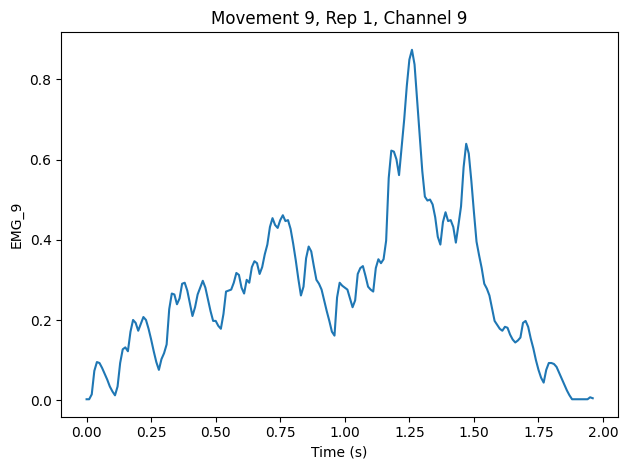

In [12]:
plot_spliced_segment(
    segments_df,
    channel=9,
    movement=9,
    repetition=1
)